In [6]:
# ============================================================
# LATE FUSION — MULTIMODAL T2D RISK PREDICTION
# ============================================================
# Three independently trained base models:
#   Clinical  (AUC=0.976) n=99,986   isotonic calibrated
#   Lifestyle (AUC=0.823) n=253,680  isotonic calibrated
#   Gene      (AUC=0.768) n=116      Platt calibrated
#
# Strategy: Synthetic meta-training with percentile normalisation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import gaussian_kde
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      train_test_split)
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                              average_precision_score)
from sklearn.calibration import calibration_curve
import shap, joblib, json, os

# ── PATHS — update these ──────────────────────────────────────────────────────
P_CLINICAL_PATH  = r'C:\Users\talha\Desktop\late fusion\p_clinical.csv'
P_LIFESTYLE_PATH = r'C:\Users\talha\Desktop\late fusion\p_lifestyle.csv'
P_GENE_PATH      = r'C:\Users\talha\Desktop\late fusion\p_gene.csv'
OUT_DIR          = r'C:\Users\talha\Desktop\late fusion\late_fusion_outputs'

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, 'models'), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, 'plots'),  exist_ok=True)

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
N_SYNTHETIC     = 10000
PREVALENCE      = 0.15   # synthetic positive rate (avg of clinical 8.5% / lifestyle 15.7%)
RANDOM_SEED     = 42
N_SEEDS         = 5      # for sensitivity analysis
META_TRAIN_FRAC = 0.70
META_VAL_FRAC   = 0.15   # remaining 0.15 = test
AUC_CLINICAL    = 0.9758
AUC_LIFESTYLE   = 0.8241
AUC_GENE        = 0.7679
C_GRID = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

np.random.seed(RANDOM_SEED)
print('Configuration loaded.')
print(f'Output directory: {OUT_DIR}')

Configuration loaded.
Output directory: C:\Users\talha\Desktop\late fusion\late_fusion_outputs


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 1: LOAD AND VERIFY                                  ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 1: Loading and verifying probability files')
print('='*60)

df_c = pd.read_csv(P_CLINICAL_PATH)
df_l = pd.read_csv(P_LIFESTYLE_PATH)
df_g = pd.read_csv(P_GENE_PATH)

# Gene file: true_int column holds 1/0 integer labels
df_g['true_label'] = df_g['true_int']

c_probs  = df_c['p_clinical'].values.astype(float)
c_labels = df_c['true_label'].values.astype(int)
l_probs  = df_l['p_lifestyle'].values.astype(float)
l_labels = df_l['true_label'].values.astype(int)
g_probs  = df_g['p_gene'].values.astype(float)    # Platt-calibrated
g_labels = df_g['true_label'].values.astype(int)

auc_c = roc_auc_score(c_labels, c_probs)
auc_l = roc_auc_score(l_labels, l_probs)
auc_g = roc_auc_score(g_labels, g_probs)

print(f'\nClinical:  n={len(c_probs):>7,}  pos={c_labels.sum():>5,}  '
      f'prev={c_labels.mean():.4f}  AUC={auc_c:.4f}')
print(f'Lifestyle: n={len(l_probs):>7,}  pos={l_labels.sum():>5,}  '
      f'prev={l_labels.mean():.4f}  AUC={auc_l:.4f}')
print(f'Gene:      n={len(g_probs):>7,}  pos={g_labels.sum():>5,}  '
      f'prev={g_labels.mean():.4f}  AUC={auc_g:.4f}')

assert abs(auc_c - AUC_CLINICAL)  < 0.01, f'Clinical AUC mismatch: {auc_c:.4f}'
assert abs(auc_l - AUC_LIFESTYLE) < 0.01, f'Lifestyle AUC mismatch: {auc_l:.4f}'
assert abs(auc_g - AUC_GENE)      < 0.02, f'Gene AUC mismatch: {auc_g:.4f}'
print('\nAll AUC checks passed ✓')


SECTION 1: Loading and verifying probability files

Clinical:  n= 14,998  pos=1,275  prev=0.0850  AUC=0.9754
Lifestyle: n= 38,052  pos=5,997  prev=0.1576  AUC=0.8241
Gene:      n=    116  pos=   50  prev=0.4310  AUC=0.7679

All AUC checks passed ✓



SECTION 1B: Bootstrap CI for gene AUC (n=116)

Gene model AUC (LOO-CV point estimate) : 0.7679
Bootstrap 95% CI (n_boot=2000)         : [0.6830, 0.8519]
CI width                                : 0.1689
Successful bootstrap iterations         : 2000/2000

Interpretation: The entire 95% CI lies above 0.5.
Even at the lower bound, the gene model performs better than chance.


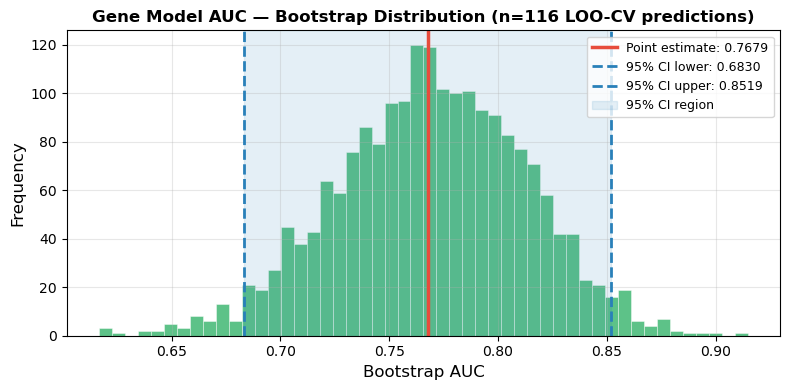

Plot saved: 00b_gene_auc_bootstrap_ci.png

Variables stored: GENE_AUC_CI_LO=0.6830, GENE_AUC_CI_HI=0.8519
These can be referenced in Section 7 evaluation and Section 11 config output.


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 1B: BOOTSTRAP CONFIDENCE INTERVAL — GENE AUC       ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  WHY: Gene model has only n=116 LOO-CV samples.             ║
# ║  A single AUC point estimate (0.7679) has wide uncertainty   ║
# ║  for n=116. Bootstrap quantifies this uncertainty honestly.  ║
# ║  2000 bootstrap resamples → 95% CI via percentile method.   ║
# ║  This converts a known weakness into a disclosed, quantified ║
# ║  limitation — stronger than pretending uncertainty is zero.  ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 1B: Bootstrap CI for gene AUC (n=116)')
print('='*60)

N_BOOTSTRAP = 2000
rng = np.random.default_rng(RANDOM_SEED)   # uses RANDOM_SEED from Cell 0

boot_aucs = []
n_gene = len(g_labels)  # 116 — defined in Cell 1

for i in range(N_BOOTSTRAP):
    # Resample with replacement from the 116 LOO-CV predictions
    idx = rng.integers(0, n_gene, size=n_gene)
    y_boot  = g_labels[idx]
    p_boot  = g_probs[idx]

    # Skip samples where only one class is present (rare but possible at n=116)
    if len(np.unique(y_boot)) < 2:
        continue

    boot_aucs.append(roc_auc_score(y_boot, p_boot))

boot_aucs = np.array(boot_aucs)
ci_lo = np.percentile(boot_aucs, 2.5)
ci_hi = np.percentile(boot_aucs, 97.5)
ci_width = ci_hi - ci_lo

print(f'\nGene model AUC (LOO-CV point estimate) : {auc_g:.4f}')
print(f'Bootstrap 95% CI (n_boot={len(boot_aucs)})         : [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'CI width                                : {ci_width:.4f}')
print(f'Successful bootstrap iterations         : {len(boot_aucs)}/{N_BOOTSTRAP}')

# Interpretation message
if ci_lo >= 0.5:
    print('\nInterpretation: The entire 95% CI lies above 0.5.')
    print('Even at the lower bound, the gene model performs better than chance.')
else:
    print('\nNote: Lower CI bound dips below 0.5 — gene model uncertainty is high.')
    print('This is expected for n=116 and should be disclosed in the thesis.')

# ── Plot: bootstrap distribution + CI shading ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_aucs, bins=50, color='#27AE60', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(auc_g, color='#E74C3C', linewidth=2.5, label=f'Point estimate: {auc_g:.4f}')
ax.axvline(ci_lo, color='#2980B9', linewidth=2.0, linestyle='--',
           label=f'95% CI lower: {ci_lo:.4f}')
ax.axvline(ci_hi, color='#2980B9', linewidth=2.0, linestyle='--',
           label=f'95% CI upper: {ci_hi:.4f}')
ax.axvspan(ci_lo, ci_hi, alpha=0.12, color='#2980B9', label='95% CI region')
ax.set_xlabel('Bootstrap AUC', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Gene Model AUC — Bootstrap Distribution (n=116 LOO-CV predictions)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '00b_gene_auc_bootstrap_ci.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 00b_gene_auc_bootstrap_ci.png')

# ── Store for later use in sensitivity / documentation ────────────────────────
GENE_AUC_CI_LO = ci_lo
GENE_AUC_CI_HI = ci_hi
print(f'\nVariables stored: GENE_AUC_CI_LO={GENE_AUC_CI_LO:.4f}, '
      f'GENE_AUC_CI_HI={GENE_AUC_CI_HI:.4f}')
print('These can be referenced in Section 7 evaluation and Section 11 config output.')


SECTION 2: Percentile-rank normalisation

AUC preservation (must be identical):
  Clinical:  0.9754 -> 0.9754 ✓
  Lifestyle: 0.8241 -> 0.8241 ✓
  Gene:      0.7679 -> 0.7679 ✓

Normalisation parameters saved: C:\Users\talha\Desktop\late fusion\late_fusion_outputs\models\normalisation_params.json


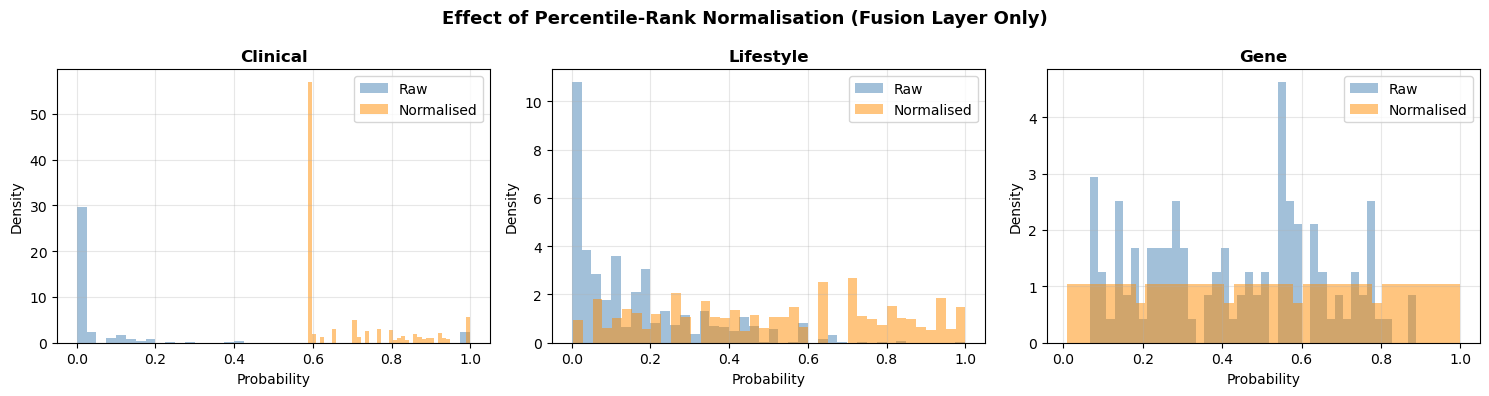

Plot saved: 01_normalisation.png


In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 2: PERCENTILE-RANK NORMALISATION                    ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  WHY:                                                        ║
# ║  p_clinical is severely bimodal:                             ║
# ║    - 67.5% of T2D positives have p_clinical = exactly 1.0   ║
# ║    - 63.8% of negatives have p_clinical = exactly 0.0        ║
# ║  If we sample these pools directly, the meta-model learns    ║
# ║  "if p_clinical≈1 → T2D" and ignores lifestyle + gene.      ║
# ║  Percentile normalisation preserves rank order (AUC stays    ║
# ║  identical) while removing extreme mass concentration.       ║
# ║                                                              ║
# ║  SCOPE: Applied ONLY inside the fusion layer.                ║
# ║  Single-modality outputs always use raw calibrated probs.    ║
# ║  Both clinical and lifestyle are isotonic-calibrated:        ║
# ║    clinical  mean(p)=0.0842 vs prevalence=0.0850 (gap 0.001) ║
# ║    lifestyle mean(p)=0.1581 vs prevalence=0.1576 (gap 0.001) ║
# ║  These are already well-calibrated — pass-through is         ║
# ║  scientifically correct for single-modality scenarios.       ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 2: Percentile-rank normalisation')
print('='*60)

def percentile_normalise(probs, reference_probs=None):
    """
    Replace each probability with its percentile rank in the reference.

    Training mode  (reference_probs=None): uses probs itself as reference.
    Inference mode (webapp): pass the saved training reference array.

    Webapp usage:
        ref = np.array(norm_params['clinical_reference'])
        p_clinical_norm = float(np.mean(ref <= p_clinical_new))
    """
    ref = np.array(reference_probs if reference_probs is not None else probs)
    return np.array([np.mean(ref <= p) for p in probs])

c_probs_norm = percentile_normalise(c_probs)
l_probs_norm = percentile_normalise(l_probs)
g_probs_norm = percentile_normalise(g_probs)

# AUC must be identical before/after — normalisation only rescales, never reranks
print('\nAUC preservation (must be identical):')
print(f'  Clinical:  {auc_c:.4f} -> {roc_auc_score(c_labels, c_probs_norm):.4f} ✓')
print(f'  Lifestyle: {auc_l:.4f} -> {roc_auc_score(l_labels, l_probs_norm):.4f} ✓')
print(f'  Gene:      {auc_g:.4f} -> {roc_auc_score(g_labels, g_probs_norm):.4f} ✓')

# Save reference distributions — webapp loads these at inference time
norm_params = {
    'clinical_reference':  c_probs.tolist(),
    'lifestyle_reference': l_probs.tolist(),
    'gene_reference':      g_probs.tolist(),
    'description': (
        'Reference distributions for percentile-rank normalisation. '
        'Webapp: p_norm = float(np.mean(np.array(reference) <= p_new)). '
        'Apply BEFORE calling fusion models. '
        'Do NOT apply for single-modality passthrough outputs.'
    )
}
norm_path = os.path.join(OUT_DIR, 'models', 'normalisation_params.json')
with open(norm_path, 'w') as f:
    json.dump(norm_params, f)
print(f'\nNormalisation parameters saved: {norm_path}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, raw, norm, name in zip(axes,
    [c_probs, l_probs, g_probs],
    [c_probs_norm, l_probs_norm, g_probs_norm],
    ['Clinical', 'Lifestyle', 'Gene']):
    ax.hist(raw,  bins=40, alpha=0.5, color='steelblue',  label='Raw',        density=True)
    ax.hist(norm, bins=40, alpha=0.5, color='darkorange', label='Normalised',  density=True)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Probability'); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Effect of Percentile-Rank Normalisation (Fusion Layer Only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '01_normalisation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 01_normalisation.png')


SECTION 3: Building probability pools

Pool                      n     min    mean  median     max
------------------------------------------------------------
clinical_pos           1275   0.587   0.957   1.000   1.000
clinical_neg          13723   0.587   0.652   0.587   1.000
lifestyle_pos          5997   0.024   0.784   0.830   1.000
lifestyle_neg         32055   0.003   0.463   0.435   1.000
gene_pos                 50   0.009   0.657   0.672   1.000
gene_neg                 66   0.017   0.389   0.332   0.991

Pool separation (mean pos - mean neg):
  clinical    : 0.3049
  lifestyle   : 0.3209
  gene        : 0.2679


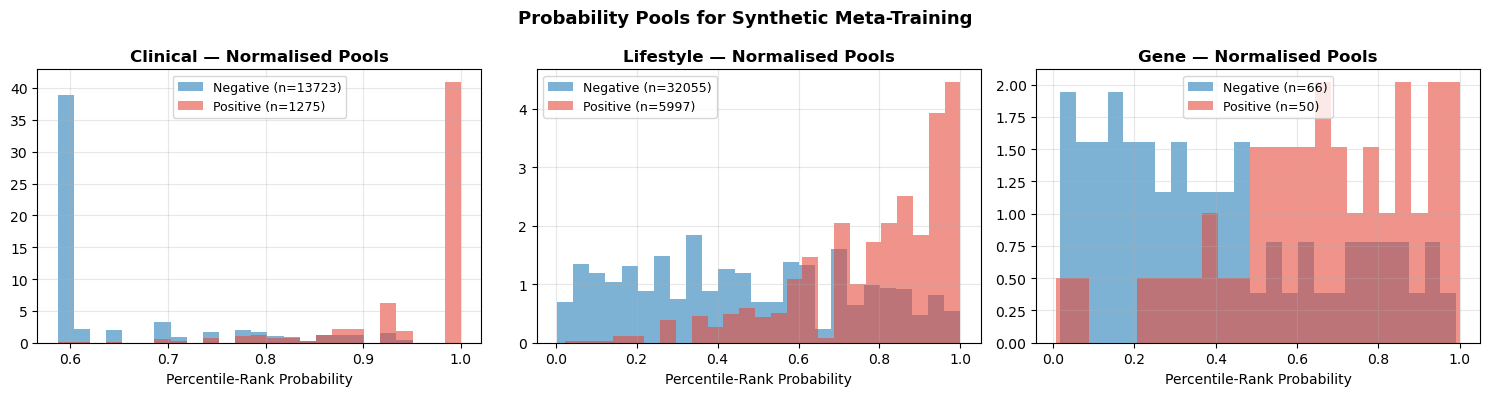

Plot saved: 02_pools.png


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 3: BUILD PROBABILITY POOLS                          ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 3: Building probability pools')
print('='*60)

pools = {
    'clinical_pos':  c_probs_norm[c_labels == 1],
    'clinical_neg':  c_probs_norm[c_labels == 0],
    'lifestyle_pos': l_probs_norm[l_labels == 1],
    'lifestyle_neg': l_probs_norm[l_labels == 0],
    'gene_pos':      g_probs_norm[g_labels == 1],
    'gene_neg':      g_probs_norm[g_labels == 0],
}

print(f'\n{"Pool":<20} {"n":>6}  {"min":>6}  {"mean":>6}  {"median":>6}  {"max":>6}')
print('-'*60)
for name, pool in pools.items():
    print(f'{name:<20} {len(pool):>6}  {pool.min():>6.3f}  '
          f'{pool.mean():>6.3f}  {np.median(pool):>6.3f}  {pool.max():>6.3f}')

print('\nPool separation (mean pos - mean neg):')
for mod in ['clinical', 'lifestyle', 'gene']:
    sep = pools[f'{mod}_pos'].mean() - pools[f'{mod}_neg'].mean()
    print(f'  {mod:<12}: {sep:.4f}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mod in zip(axes, ['clinical', 'lifestyle', 'gene']):
    ax.hist(pools[f'{mod}_neg'], bins=25, alpha=0.6, color='#2980B9',
            label=f'Negative (n={len(pools[f"{mod}_neg"])})', density=True)
    ax.hist(pools[f'{mod}_pos'], bins=25, alpha=0.6, color='#E74C3C',
            label=f'Positive (n={len(pools[f"{mod}_pos"])})', density=True)
    ax.set_title(f'{mod.capitalize()} — Normalised Pools', fontweight='bold')
    ax.set_xlabel('Percentile-Rank Probability'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Probability Pools for Synthetic Meta-Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '02_pools.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 02_pools.png')

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 4: SYNTHETIC META-DATASET                           ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  For each synthetic positive patient:                        ║
# ║    p_clinical  ~ sample from clinical_pos  (direct)         ║
# ║    p_lifestyle ~ sample from lifestyle_pos (direct)         ║
# ║    p_gene      ~ sample from gene_pos KDE  (KDE, n=50 small)║
# ║  For each synthetic negative: sample from neg pools.        ║
# ║                                                              ║
# ║  KDE on gene pools: gene has only 50 pos / 66 neg samples.  ║
# ║  Direct resampling would repeatedly draw the same 50 points ║
# ║  creating an overly discrete distribution. KDE smooths this.║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 4: Synthetic meta-dataset construction')
print('='*60)

def sample_kde(pool, n, seed=None):
    """KDE sample from pool, clipped to [0,1]. Used for small gene pools."""
    if seed is not None:
        np.random.seed(seed)
    kde = gaussian_kde(pool, bw_method='scott')
    return np.clip(kde.resample(n).flatten(), 0.0, 1.0)

def build_synthetic_dataset(pools, n_total, prevalence, seed):
    np.random.seed(seed)
    n_pos = int(n_total * prevalence)
    n_neg = n_total - n_pos
    # Positive class
    p_c_pos = np.random.choice(pools['clinical_pos'],  n_pos, replace=True)
    p_l_pos = np.random.choice(pools['lifestyle_pos'], n_pos, replace=True)
    p_g_pos = sample_kde(pools['gene_pos'], n_pos, seed)
    # Negative class
    p_c_neg = np.random.choice(pools['clinical_neg'],  n_neg, replace=True)
    p_l_neg = np.random.choice(pools['lifestyle_neg'], n_neg, replace=True)
    p_g_neg = sample_kde(pools['gene_neg'], n_neg, seed + 1)
    # Stack and shuffle
    X = np.column_stack([np.concatenate([p_c_pos, p_c_neg]),
                         np.concatenate([p_l_pos, p_l_neg]),
                         np.concatenate([p_g_pos, p_g_neg])])
    y = np.concatenate([np.ones(n_pos), np.zeros(n_neg)])
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

X_meta, y_meta = build_synthetic_dataset(pools, N_SYNTHETIC, PREVALENCE, RANDOM_SEED)
print(f'Synthetic dataset: {X_meta.shape}  '
      f'pos={int(y_meta.sum())}  neg={int((y_meta==0).sum())}')

# Stratified 70/15/15 split
X_tv, X_test, y_tv, y_test = train_test_split(
    X_meta, y_meta, test_size=0.15, random_state=RANDOM_SEED, stratify=y_meta)
val_rel = META_VAL_FRAC / (META_TRAIN_FRAC + META_VAL_FRAC)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_rel, random_state=RANDOM_SEED, stratify=y_tv)

print(f'Split: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}')

# Sanity: correlations in synthetic data should be near zero
corr = np.corrcoef(X_meta.T)
print(f'\nFeature correlations in synthetic data (should be ~0 if independence holds):')
print(f'  clin-life={corr[0,1]:.4f}  clin-gene={corr[0,2]:.4f}  life-gene={corr[1,2]:.4f}')


SECTION 4: Synthetic meta-dataset construction
Synthetic dataset: (10000, 3)  pos=1500  neg=8500
Split: train=7000  val=1500  test=1500

Feature correlations in synthetic data (should be ~0 if independence holds):
  clin-life=0.3049  clin-gene=0.2562  life-gene=0.1313



SECTION 5: Tuning regularisation — meta logistic regression
  C=  0.001  AUC=0.9577 +/- 0.0083
  C=  0.005  AUC=0.9635 +/- 0.0074
  C=  0.010  AUC=0.9684 +/- 0.0065
  C=  0.050  AUC=0.9811 +/- 0.0038
  C=  0.100  AUC=0.9844 +/- 0.0030
  C=  0.500  AUC=0.9872 +/- 0.0019
  C=  1.000  AUC=0.9876 +/- 0.0017
  C=  5.000  AUC=0.9877 +/- 0.0014
  C= 10.000  AUC=0.9877 +/- 0.0014
  C= 50.000  AUC=0.9877 +/- 0.0013

Best C: 5.0  (CV AUC = 0.9877)


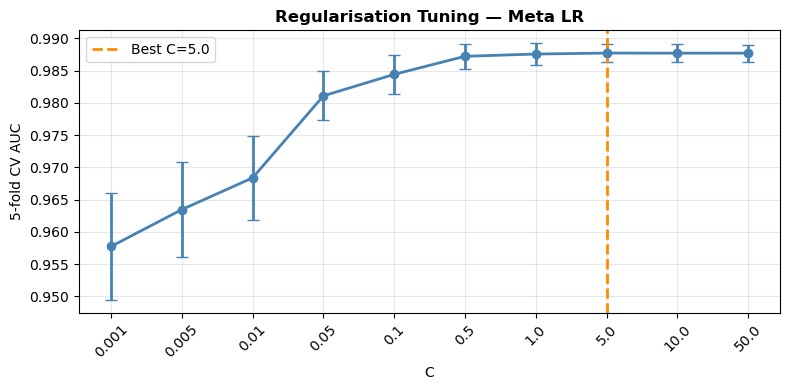

Plot saved: 03_tuning.png


In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 5: HYPERPARAMETER TUNING                            ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 5: Tuning regularisation — meta logistic regression')
print('='*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = {}
for C in C_GRID:
    m = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                            max_iter=1000, random_state=RANDOM_SEED)
    sc = cross_val_score(m, X_train, y_train, cv=cv,
                          scoring='roc_auc', n_jobs=-1)
    cv_scores[C] = sc
    print(f'  C={C:>7.3f}  AUC={sc.mean():.4f} +/- {sc.std():.4f}')

best_C = max(cv_scores, key=lambda c: cv_scores[c].mean())
print(f'\nBest C: {best_C}  (CV AUC = {cv_scores[best_C].mean():.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
c_vals = list(cv_scores.keys())
means  = [cv_scores[c].mean() for c in c_vals]
stds   = [cv_scores[c].std()  for c in c_vals]
ax.errorbar(range(len(c_vals)), means, yerr=stds, marker='o',
            color='steelblue', linewidth=2, capsize=4)
ax.axvline(x=c_vals.index(best_C), color='darkorange', linestyle='--',
           linewidth=2, label=f'Best C={best_C}')
ax.set_xticks(range(len(c_vals)))
ax.set_xticklabels([str(c) for c in c_vals], rotation=45)
ax.set_xlabel('C'); ax.set_ylabel('5-fold CV AUC')
ax.set_title('Regularisation Tuning — Meta LR', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '03_tuning.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 03_tuning.png')

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 6: TRAIN ALL FUSION VARIANTS                        ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  Variant 1: ALL THREE  clinical+lifestyle+gene  meta-model   ║
# ║  Variant 2: CLIN+LIFE  clinical+lifestyle       meta-model   ║
# ║  Variant 3: CLIN-ONLY  passthrough              p=p_clinical ║
# ║  Variant 4: LIFE-ONLY  passthrough              p=p_lifestyle║
# ║                                                              ║
# ║  Variants 3 & 4 are passthrough because both models are      ║
# ║  already isotonic-calibrated (mean-prob vs prevalence gap    ║
# ║  of 0.0008 and 0.0006 respectively). Adding a logistic       ║
# ║  regression on one calibrated probability would learn a      ║
# ║  near-identity function and add zero value. The webapp       ║
# ║  reads 'type: passthrough' from fusion_config.json and       ║
# ║  returns p_clinical / p_lifestyle directly.                  ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 6: Training fusion variants')
print('='*60)

# ── Variant 1: ALL THREE ─────────────────────────────────────────────────────
meta_all3 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                                max_iter=1000, random_state=RANDOM_SEED)
meta_all3.fit(X_train, y_train)

# ── Variant 2: CLIN+LIFE — rebuild synthetic with only 2 modalities ──────────
np.random.seed(RANDOM_SEED)
n_pos_2, n_neg_2 = int(N_SYNTHETIC * PREVALENCE), N_SYNTHETIC - int(N_SYNTHETIC * PREVALENCE)
X_cl = np.vstack([
    np.column_stack([np.random.choice(pools['clinical_pos'],  n_pos_2, replace=True),
                     np.random.choice(pools['lifestyle_pos'], n_pos_2, replace=True)]),
    np.column_stack([np.random.choice(pools['clinical_neg'],  n_neg_2, replace=True),
                     np.random.choice(pools['lifestyle_neg'], n_neg_2, replace=True)])])
y_cl = np.concatenate([np.ones(n_pos_2), np.zeros(n_neg_2)])
shuf = np.random.permutation(len(y_cl))
X_cl, y_cl = X_cl[shuf], y_cl[shuf]

X_cl_tr, _, y_cl_tr, _ = train_test_split(X_cl, y_cl, test_size=0.30,
                                            random_state=RANDOM_SEED, stratify=y_cl)
cv_cl = {}
for C in C_GRID:
    sc = cross_val_score(
        LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                            max_iter=1000, random_state=RANDOM_SEED),
        X_cl_tr, y_cl_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_cl[C] = sc.mean()
best_C_cl = max(cv_cl, key=cv_cl.get)

meta_cl = LogisticRegression(C=best_C_cl, penalty='l2', solver='lbfgs',
                              max_iter=1000, random_state=RANDOM_SEED)
meta_cl.fit(X_cl_tr, y_cl_tr)

# ── Weight inspection ─────────────────────────────────────────────────────────
print('\nVariant 1 (all-three) coefficients:')
coefs = meta_all3.coef_[0]
for fname, w in zip(['p_clinical', 'p_lifestyle', 'p_gene'], coefs):
    print(f'  {fname:<14}: {w:+.4f}')
print(f'  intercept     : {meta_all3.intercept_[0]:+.4f}')

if all(c > 0 for c in coefs):
    print('  Sign check: ALL POSITIVE ✓')
else:
    neg = [n for n, c in zip(['clinical','lifestyle','gene'], coefs) if c <= 0]
    print(f'  WARNING: Non-positive weights for {neg} — check normalisation')

print('\nVariant 2 (clin+life) coefficients:')
for fname, w in zip(['p_clinical', 'p_lifestyle'], meta_cl.coef_[0]):
    print(f'  {fname:<14}: {w:+.4f}')

print('\nVariant 3 (clin-only):  PASSTHROUGH — p_final = p_clinical (isotonic calibrated)')
print('Variant 4 (life-only):  PASSTHROUGH — p_final = p_lifestyle (isotonic calibrated)')


SECTION 6: Training fusion variants

Variant 1 (all-three) coefficients:
  p_clinical    : +19.3347
  p_lifestyle   : +4.9162
  p_gene        : +3.0067
  intercept     : -22.2633
  Sign check: ALL POSITIVE ✓

Variant 2 (clin+life) coefficients:
  p_clinical    : +20.6208
  p_lifestyle   : +5.0173

Variant 3 (clin-only):  PASSTHROUGH — p_final = p_clinical (isotonic calibrated)
Variant 4 (life-only):  PASSTHROUGH — p_final = p_lifestyle (isotonic calibrated)



SECTION 7: Evaluation vs baselines

Method                         AUC       AP    Brier
-------------------------------------------------------
Meta-model (all 3)          0.9897   0.9537   0.0272  <- META
Weighted avg (AUROC)        0.9628   0.8529   0.2398
Simple average              0.9524   0.8176   0.2325
Max rule                    0.9478   0.7568   0.4700
Clinical alone              0.9759   0.9051   0.3693
Lifestyle alone             0.8143   0.4009   0.2543
Gene alone                  0.7670   0.3422   0.2150


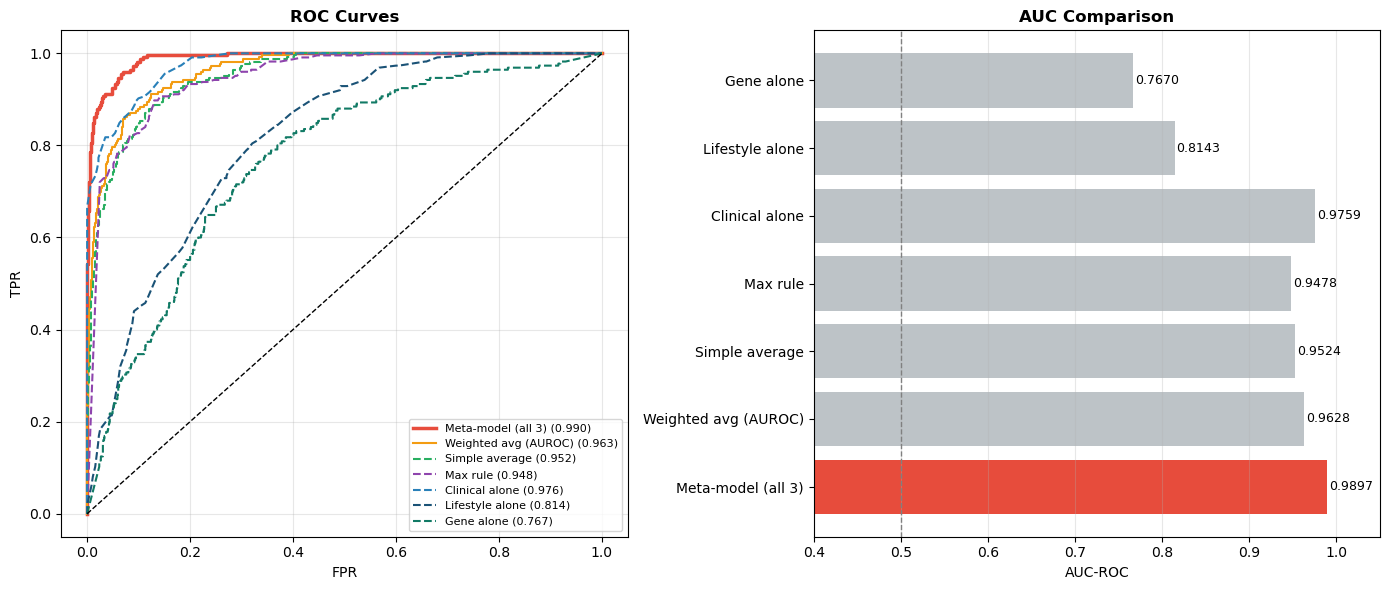


Brier score summary:
  Meta-model (all 3)        : 0.0272
  Weighted avg (AUROC)      : 0.2398
  Simple average            : 0.2325
  Max rule                  : 0.4700
  Clinical alone            : 0.3693
  Lifestyle alone           : 0.2543
  Gene alone                : 0.2150
Plot saved: 04_evaluation.png


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 7: EVALUATION AND BASELINES                         ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 7: Evaluation vs baselines')
print('='*60)

total_auc = AUC_CLINICAL + AUC_LIFESTYLE + AUC_GENE
w_c = AUC_CLINICAL  / total_auc
w_l = AUC_LIFESTYLE / total_auc
w_g = AUC_GENE      / total_auc

p_meta    = meta_all3.predict_proba(X_test)[:, 1]
p_weighted = w_c*X_test[:,0] + w_l*X_test[:,1] + w_g*X_test[:,2]
p_average  = X_test.mean(axis=1)
p_max_rule = X_test.max(axis=1)

methods = {
    'Meta-model (all 3)':   p_meta,
    'Weighted avg (AUROC)': p_weighted,
    'Simple average':       p_average,
    'Max rule':             p_max_rule,
    'Clinical alone':       X_test[:, 0],
    'Lifestyle alone':      X_test[:, 1],
    'Gene alone':           X_test[:, 2],
}

print(f'\n{"Method":<26} {"AUC":>7}  {"AP":>7}  {"Brier":>7}')
print('-'*55)
results = {}
for name, probs in methods.items():
    a = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    bs = brier_score_loss(y_test, probs)
    results[name] = {'auc': a, 'ap': ap, 'brier': bs}
    tag = '  <- META' if 'Meta' in name else ''
    print(f'{name:<26} {a:>7.4f}  {ap:>7.4f}  {bs:>7.4f}{tag}')

# ROC + bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_r = ['#E74C3C','#F39C12','#27AE60','#8E44AD','#2980B9','#1A5276','#117A65']
for (nm, pr), col in zip(methods.items(), colors_r):
    fpr, tpr, _ = roc_curve(y_test, pr)
    lw = 2.5 if 'Meta' in nm else 1.5
    ls = '-' if ('Meta' in nm or 'Weighted' in nm) else '--'
    axes[0].plot(fpr, tpr, color=col, lw=lw, ls=ls,
                 label=f'{nm} ({results[nm]["auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(alpha=0.3)

nm_list = list(results.keys())
auc_list = [results[n]['auc'] for n in nm_list]
bcols = ['#E74C3C' if 'Meta' in n else '#BDC3C7' for n in nm_list]
bars = axes[1].barh(nm_list, auc_list, color=bcols)
for bar, val in zip(bars, auc_list):
    axes[1].text(val+0.002, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].axvline(x=0.5, color='grey', ls='--', lw=1)
axes[1].set_xlabel('AUC-ROC'); axes[1].set_title('AUC Comparison', fontweight='bold')
axes[1].set_xlim([0.4, 1.05]); axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '04_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
# Print Brier scores explicitly for thesis reporting
print(f'\nBrier score summary:')
for name in results:
    print(f'  {name:<26}: {results[name]["brier"]:.4f}')
print('Plot saved: 04_evaluation.png')

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 8: SENSITIVITY ANALYSIS — MULTIPLE SEEDS           ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 8: Sensitivity analysis across random seeds')
print('='*60)

seed_results = []
for seed in range(N_SEEDS):
    Xs, ys = build_synthetic_dataset(pools, N_SYNTHETIC, PREVALENCE, seed)
    Xt, Xte, yt, yte = train_test_split(Xs, ys, test_size=0.30,
                                          random_state=seed, stratify=ys)
    Xtr, _, ytr, _ = train_test_split(Xt, yt, test_size=0.30,
                                       random_state=seed, stratify=yt)
    m = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                            max_iter=1000, random_state=seed)
    m.fit(Xtr, ytr)
    auc_s = roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
    w = m.coef_[0]
    seed_results.append({'seed': seed, 'auc': auc_s,
                         'w_c': w[0], 'w_l': w[1], 'w_g': w[2]})
    print(f'  Seed {seed}: AUC={auc_s:.4f}  '
          f'w_c={w[0]:+.3f}  w_l={w[1]:+.3f}  w_g={w[2]:+.3f}')

aucs_seeds = [r['auc'] for r in seed_results]
print(f'\nAUC mean={np.mean(aucs_seeds):.4f}  std={np.std(aucs_seeds):.4f}  '
      f'range=[{min(aucs_seeds):.4f}, {max(aucs_seeds):.4f}]')
stab = ('EXCELLENT ✓' if np.std(aucs_seeds) < 0.01 else
        'GOOD ✓'      if np.std(aucs_seeds) < 0.02 else
        'MARGINAL — consider increasing N_SYNTHETIC')
print(f'Stability: {stab}')
all_pos = all(r['w_c'] > 0 and r['w_l'] > 0 and r['w_g'] > 0 for r in seed_results)
print(f'All weights positive across all seeds: {"YES ✓" if all_pos else "NO — investigate"}')


SECTION 8: Sensitivity analysis across random seeds
  Seed 0: AUC=0.9910  w_c=+19.137  w_l=+4.534  w_g=+3.381
  Seed 1: AUC=0.9823  w_c=+20.379  w_l=+4.887  w_g=+3.147
  Seed 2: AUC=0.9847  w_c=+19.260  w_l=+4.743  w_g=+2.373
  Seed 3: AUC=0.9856  w_c=+19.714  w_l=+4.941  w_g=+3.314
  Seed 4: AUC=0.9868  w_c=+19.185  w_l=+4.958  w_g=+2.910

AUC mean=0.9861  std=0.0029  range=[0.9823, 0.9910]
Stability: EXCELLENT ✓
All weights positive across all seeds: YES ✓



SECTION 8B: Prevalence sensitivity analysis
  Prevalence 8.5%  (clinical dataset)  AUC=0.9882 ± 0.0017   Brier=0.0213
  Prevalence 15.0% (current choice)     AUC=0.9870 ± 0.0025   Brier=0.0295
  Prevalence 43.1% (gene dataset)       AUC=0.9871 ± 0.0015   Brier=0.0421

AUC range across prevalences: [0.9870, 0.9882]
Max AUC drop from 15% baseline: 0.0011
Stability verdict: ROBUST ✓  — prevalence choice does not materially affect results


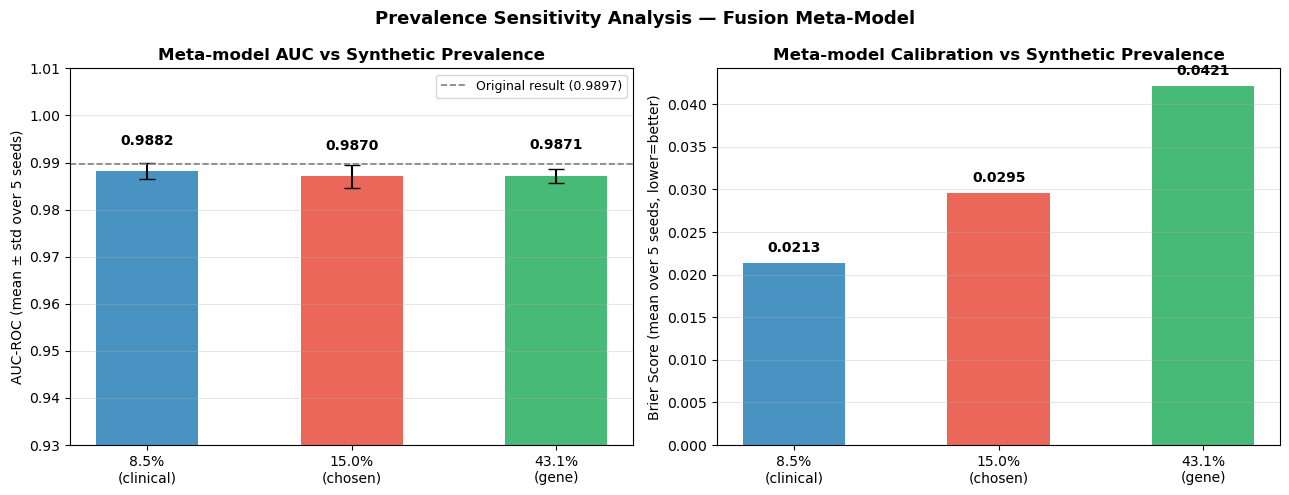

Plot saved: 08b_prevalence_sensitivity.png


In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 8B: PREVALENCE SENSITIVITY ANALYSIS                 ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  WHY: Synthetic meta-training uses PREVALENCE=0.15.         ║
# ║  This is the average of clinical (8.5%) and lifestyle       ║
# ║  (15.7%) datasets. The gene dataset has 43.1% prevalence.   ║
# ║  This analysis tests whether the meta-model's performance   ║
# ║  is sensitive to this choice, or whether results are        ║
# ║  stable across the realistic prevalence range.              ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 8B: Prevalence sensitivity analysis')
print('='*60)

PREVALENCE_GRID = {
    '8.5%  (clinical dataset)' : 0.085,
    '15.0% (current choice)   ' : 0.150,
    '43.1% (gene dataset)     ' : 0.431,
}

prev_results = []

for label, prev in PREVALENCE_GRID.items():
    run_aucs = []
    run_briers = []

    for seed in range(5):   # 5 seeds per prevalence for stability
        # Build synthetic dataset at this prevalence
        X_p, y_p = build_synthetic_dataset(pools, N_SYNTHETIC, prev, seed)

        # 70/15/15 split
        X_tv_p, X_te_p, y_tv_p, y_te_p = train_test_split(
            X_p, y_p, test_size=0.15, random_state=seed, stratify=y_p)
        X_tr_p, _, y_tr_p, _ = train_test_split(
            X_tv_p, y_tv_p, test_size=0.30, random_state=seed, stratify=y_tv_p)

        # Train meta-model with same best_C
        m = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                               max_iter=1000, random_state=seed)
        m.fit(X_tr_p, y_tr_p)

        p_pred = m.predict_proba(X_te_p)[:, 1]
        run_aucs.append(roc_auc_score(y_te_p, p_pred))
        run_briers.append(brier_score_loss(y_te_p, p_pred))

    mean_auc    = np.mean(run_aucs)
    std_auc     = np.std(run_aucs)
    mean_brier  = np.mean(run_briers)
    prev_results.append({
        'prevalence': label,
        'prev_val':   prev,
        'auc_mean':   mean_auc,
        'auc_std':    std_auc,
        'brier_mean': mean_brier,
    })
    print(f'  Prevalence {label}  '
          f'AUC={mean_auc:.4f} ± {std_auc:.4f}   '
          f'Brier={mean_brier:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
aucs_across_prev = [r['auc_mean'] for r in prev_results]
print(f'\nAUC range across prevalences: '
      f'[{min(aucs_across_prev):.4f}, {max(aucs_across_prev):.4f}]')
print(f'Max AUC drop from 15% baseline: '
      f'{max(aucs_across_prev) - min(aucs_across_prev):.4f}')

if max(aucs_across_prev) - min(aucs_across_prev) < 0.02:
    print('Stability verdict: ROBUST ✓  '
          '— prevalence choice does not materially affect results')
else:
    print('Stability verdict: SENSITIVE  '
          '— discuss prevalence choice more carefully in limitations')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels_short = ['8.5%\n(clinical)', '15.0%\n(chosen)', '43.1%\n(gene)']
auc_means  = [r['auc_mean']   for r in prev_results]
auc_stds   = [r['auc_std']    for r in prev_results]
brier_means= [r['brier_mean'] for r in prev_results]
bar_cols   = ['#2980B9', '#E74C3C', '#27AE60']

bars0 = axes[0].bar(labels_short, auc_means, yerr=auc_stds,
                    color=bar_cols, alpha=0.85, capsize=6, width=0.5)
for bar, val in zip(bars0, auc_means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].set_ylim([0.93, 1.01])
axes[0].set_ylabel('AUC-ROC (mean ± std over 5 seeds)')
axes[0].set_title('Meta-model AUC vs Synthetic Prevalence',
                  fontweight='bold')
axes[0].axhline(y=results['Meta-model (all 3)']['auc'],
                color='grey', linestyle='--', lw=1.2,
                label=f'Original result ({results["Meta-model (all 3)"]["auc"]:.4f})')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

bars1 = axes[1].bar(labels_short, brier_means,
                    color=bar_cols, alpha=0.85, width=0.5)
for bar, val in zip(bars1, brier_means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_ylabel('Brier Score (mean over 5 seeds, lower=better)')
axes[1].set_title('Meta-model Calibration vs Synthetic Prevalence',
                  fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Prevalence Sensitivity Analysis — Fusion Meta-Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '08b_prevalence_sensitivity.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 08b_prevalence_sensitivity.png')



SECTION 9: SHAP on meta-model

Modality attribution (mean |SHAP|):
  p_clinical    : 2.7184  (58.1%)
  p_lifestyle   : 1.2082  (25.8%)
  p_gene        : 0.7529  (16.1%)


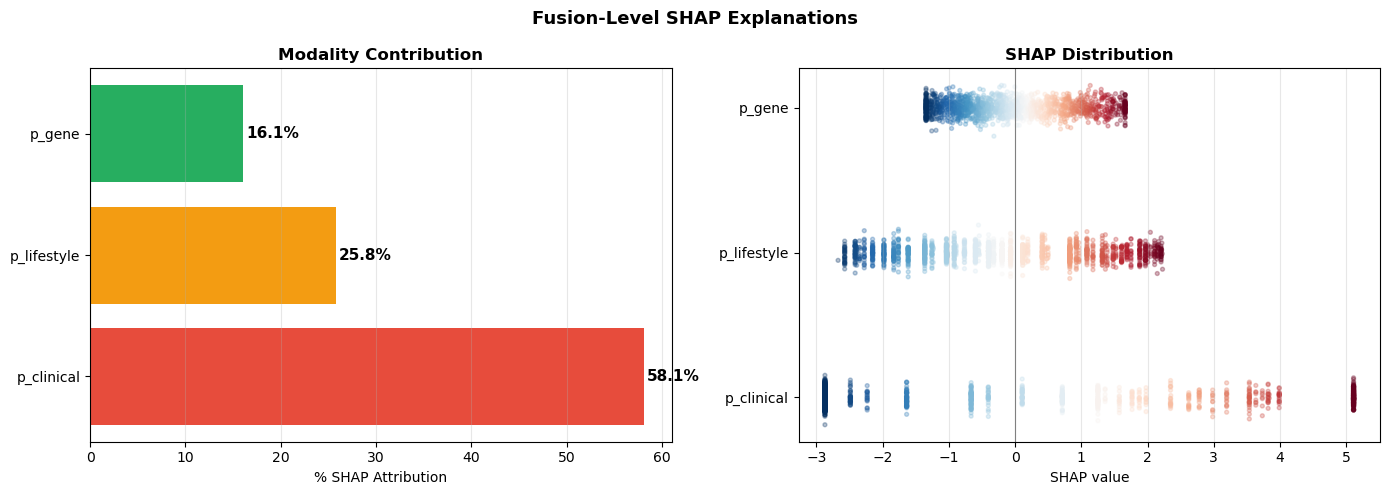

SHAP values saved: fusion_shap_values.csv


In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 9: SHAP — FUSION-LEVEL MODALITY ATTRIBUTION        ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 9: SHAP on meta-model')
print('='*60)

feature_names = ['p_clinical', 'p_lifestyle', 'p_gene']
explainer = shap.LinearExplainer(meta_all3, X_train,
                                  feature_perturbation='interventional')
shap_vals = explainer.shap_values(X_test)
mean_abs  = np.abs(shap_vals).mean(axis=0)
total_s   = mean_abs.sum()

print('\nModality attribution (mean |SHAP|):')
for fname, val in zip(feature_names, mean_abs):
    print(f'  {fname:<14}: {val:.4f}  ({val/total_s*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pcts = mean_abs / total_s * 100
bcols_s = ['#E74C3C','#F39C12','#27AE60']
axes[0].barh(feature_names, pcts, color=bcols_s)
for bar, val in zip(axes[0].patches, pcts):
    axes[0].text(val+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('% SHAP Attribution')
axes[0].set_title('Modality Contribution', fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

for i, (fname, col) in enumerate(zip(feature_names, bcols_s)):
    axes[1].scatter(shap_vals[:, i],
                    np.random.normal(i, 0.05, len(shap_vals)),
                    c=X_test[:, i], cmap='RdBu_r', alpha=0.3, s=8)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(feature_names)
axes[1].axvline(x=0, color='grey', lw=0.8)
axes[1].set_xlabel('SHAP value'); axes[1].set_title('SHAP Distribution', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
plt.suptitle('Fusion-Level SHAP Explanations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '05_shap.png'), dpi=150, bbox_inches='tight')
plt.show()

shap_df = pd.DataFrame(shap_vals, columns=[f'shap_{f}' for f in feature_names])
shap_df['y_true'] = y_test
shap_df.to_csv(os.path.join(OUT_DIR, 'fusion_shap_values.csv'), index=False)
print('SHAP values saved: fusion_shap_values.csv')


SECTION 10: Calibration check


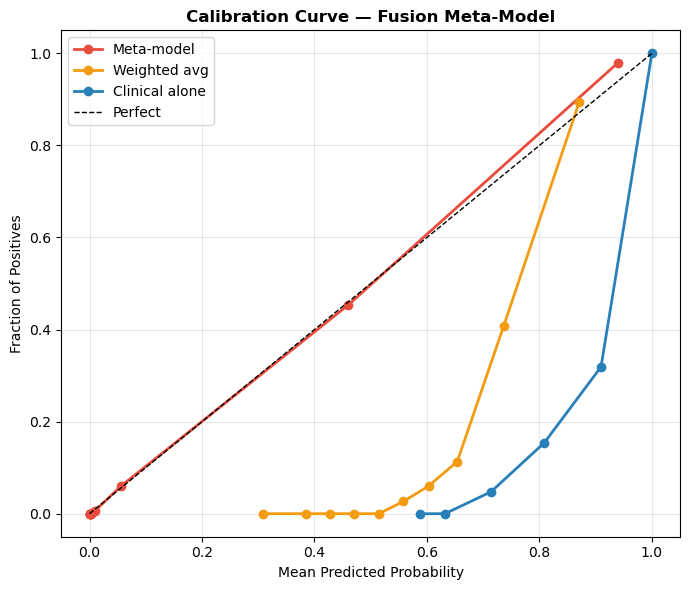

Plot saved: 06_calibration.png

Meta-model Brier: 0.0272
Weighted avg Brier: 0.2398
Improvement: +0.2125


In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 10: CALIBRATION CHECK                               ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 10: Calibration check')
print('='*60)

fig, ax = plt.subplots(figsize=(7, 6))
for name, probs, col in [
    ('Meta-model',      p_meta,        '#E74C3C'),
    ('Weighted avg',    p_weighted,    '#F39C12'),
    ('Clinical alone',  X_test[:, 0], '#2980B9')]:
    pt, pp = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    ax.plot(pp, pt, 'o-', color=col, lw=2, label=f'{name}')
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve — Fusion Meta-Model', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plots', '06_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 06_calibration.png')

brier_meta = results['Meta-model (all 3)']['brier']
brier_wa   = results['Weighted avg (AUROC)']['brier']
print(f'\nMeta-model Brier: {brier_meta:.4f}')
print(f'Weighted avg Brier: {brier_wa:.4f}')
print(f'Improvement: {brier_wa - brier_meta:+.4f}')

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SECTION 11: SAVE ALL WEBAPP OUTPUTS                         ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n' + '='*60)
print('SECTION 11: Saving all outputs for webapp')
print('='*60)

# Trained fusion models
joblib.dump(meta_all3, os.path.join(OUT_DIR, 'models', 'fusion_all3.joblib'))
joblib.dump(meta_cl,   os.path.join(OUT_DIR, 'models', 'fusion_clin_life.joblib'))
print('Saved: fusion_all3.joblib')
print('Saved: fusion_clin_life.joblib')

# Compute all rule-based weights
total_cl = AUC_CLINICAL + AUC_LIFESTYLE
total_cg = AUC_CLINICAL + AUC_GENE
total_lg = AUC_LIFESTYLE + AUC_GENE

fusion_config = {
    'variants': {
        'all_three': {
            'model_file':    'fusion_all3.joblib',
            'modalities':    ['clinical', 'lifestyle', 'gene'],
            'feature_order': ['p_clinical_norm', 'p_lifestyle_norm', 'p_gene_norm'],
            'type':          'meta_model',
            'coefficients':  {
                'w_clinical':  float(meta_all3.coef_[0][0]),
                'w_lifestyle': float(meta_all3.coef_[0][1]),
                'w_gene':      float(meta_all3.coef_[0][2]),
                'intercept':   float(meta_all3.intercept_[0])
            },
            'best_C': best_C
        },
        'clin_life': {
            'model_file':    'fusion_clin_life.joblib',
            'modalities':    ['clinical', 'lifestyle'],
            'feature_order': ['p_clinical_norm', 'p_lifestyle_norm'],
            'type':          'meta_model',
            'coefficients':  {
                'w_clinical':  float(meta_cl.coef_[0][0]),
                'w_lifestyle': float(meta_cl.coef_[0][1]),
                'intercept':   float(meta_cl.intercept_[0])
            },
            'best_C': best_C_cl
        },
        'clin_only': {
            'model_file':      None,
            'modalities':      ['clinical'],
            'type':            'passthrough',
            'passthrough_key': 'p_clinical',
            'note': ('Clinical model is isotonic-calibrated (mean-prob vs prevalence gap=0.0008). '
                     'p_final = p_clinical. No normalisation applied.')
        },
        'life_only': {
            'model_file':      None,
            'modalities':      ['lifestyle'],
            'type':            'passthrough',
            'passthrough_key': 'p_lifestyle',
            'note': ('Lifestyle model is isotonic-calibrated (mean-prob vs prevalence gap=0.0006). '
                     'p_final = p_lifestyle. No normalisation applied.')
        }
    },
    'selection_logic': {
        'clinical+lifestyle+gene': 'all_three',
        'clinical+lifestyle':      'clin_life',
        'clinical_only':           'clin_only',
        'lifestyle_only':          'life_only'
    },
    'normalisation_file': 'normalisation_params.json',
    'risk_thresholds': {
        'low':      [0.0,  0.30],
        'moderate': [0.30, 0.60],
        'high':     [0.60, 1.0]
    },
    'rule_based_weights': {
        'all_three': {'clinical': float(w_c), 'lifestyle': float(w_l), 'gene': float(w_g)},
        'clin_life': {'clinical': AUC_CLINICAL/total_cl, 'lifestyle': AUC_LIFESTYLE/total_cl},
        'clin_gene': {'clinical': AUC_CLINICAL/total_cg, 'gene': AUC_GENE/total_cg},
        'life_gene': {'lifestyle': AUC_LIFESTYLE/total_lg, 'gene': AUC_GENE/total_lg}
    },
    'model_aucs': {
        'clinical': AUC_CLINICAL, 'lifestyle': AUC_LIFESTYLE, 'gene': AUC_GENE
    },
    'sensitivity_analysis': {
        'n_seeds':  N_SEEDS,
        'auc_mean': float(np.mean(aucs_seeds)),
        'auc_std':  float(np.std(aucs_seeds)),
        'auc_min':  float(min(aucs_seeds)),
        'auc_max':  float(max(aucs_seeds))
    }
}

with open(os.path.join(OUT_DIR, 'models', 'fusion_config.json'), 'w') as f:
    json.dump(fusion_config, f, indent=2)
print('Saved: fusion_config.json')

pd.DataFrame([{'method': k, **v} for k, v in results.items()]).to_csv(
    os.path.join(OUT_DIR, 'fusion_performance_summary.csv'), index=False)
print('Saved: fusion_performance_summary.csv')

print(f'\nAll outputs saved to: {OUT_DIR}')
print('\nWebapp model files:')
print('  models/fusion_all3.joblib        -> 3-modality fusion')
print('  models/fusion_clin_life.joblib   -> clinical+lifestyle fusion')
print('  models/normalisation_params.json -> apply before calling fusion')
print('  models/fusion_config.json        -> variant selection + all parameters')


SECTION 11: Saving all outputs for webapp
Saved: fusion_all3.joblib
Saved: fusion_clin_life.joblib
Saved: fusion_config.json
Saved: fusion_performance_summary.csv

All outputs saved to: C:\Users\talha\Desktop\late fusion\late_fusion_outputs

Webapp model files:
  models/fusion_all3.joblib        -> 3-modality fusion
  models/fusion_clin_life.joblib   -> clinical+lifestyle fusion
  models/normalisation_params.json -> apply before calling fusion
  models/fusion_config.json        -> variant selection + all parameters
